# 🚢 Duelo de Modelos IV — Previsão de Sobrevivência no Titanic (v2)

**Projeto de Machine Learning ponta a ponta** aplicado à clássica competição *Titanic — Machine Learning from Disaster* do Kaggle.

**Objetivo:** superar, com técnicas mais avançadas de tratamento de dados, engenharia de atributos, validação cruzada e otimização de hiperparâmetros, o desempenho obtido em aula, colocando quatro algoritmos (Regressão Logística, Random Forest, SVM e XGBoost) em um "duelo" justo e reprodutível — e melhorar o resultado obtido na primeira submissão real ao Kaggle.

**Autor:** Talita Luci · MSc.Engenharia Mecânica · Curso EBAC — Profissão: Cientista de Dados (Módulo 41)


## Enunciado da Atividade

Nesta tarefa, vocês irão criar o seu próprio duelo de modelos, com o objetivo de superar os resultados apresentados em aula. O desafio é alcançar um desempenho superior ao que obtivemos, e para isso, será necessário aplicar todas as melhorias que vocês aprenderam ao longo dos módulos, utilizando a base de dados do Titanic.

**1. Escolha do Modelo:** selecionar um dos modelos explorados nos duelos anteriores (SVM, Random Forest, XGBoost, etc.).

**2. Aperfeiçoamento:** aplicar hiperparâmetros (GridSearchCV/RandomizedSearchCV), validação cruzada, balanceamento de classes e padronização/normalização dos dados.

**3. Submissão no Kaggle:** treinar com os dados de treino e gerar previsões para os dados de teste, submetendo à competição.

**4. Entrega:** código documentado, explicando cada etapa e as escolhas de modelagem, junto do print do score no Kaggle.

**5. Competição saudável:** inovar e não replicar exatamente o que foi feito em aula.


## Metodologia deste notebook (v2 — iteração após feedback real do Kaggle)

Este notebook é a **segunda iteração** do projeto. A primeira versão (v1) foi submetida ao Kaggle e pontuou **0,755** — abaixo inclusive do baseline público "apenas sexo" (0,76555). O diagnóstico dessa diferença entre a validação interna (holdout ≈ 0,80) e o score real do Kaggle está na Seção 1.5, e motiva todas as mudanças de engenharia e modelagem feitas aqui.

1. **Análise Exploratória de Dados (EDA)**.
2. **Diagnóstico da v1 e plano de melhoria** *(novo)*.
3. **Tratamento de dados e Engenharia de Atributos (v2)** — imputação sem vazamento, atributos enxutos e o atributo de sobrevivência familiar/grupo.
4. **Preparação para modelagem** — split treino/teste, padronização e balanceamento **via pesos de classe** (sem SMOTE).
5. **Duelo de Modelos (baseline)** — validação cruzada estratificada (k=10).
6. **Otimização de hiperparâmetros** — GridSearchCV nos finalistas.
7. **Ensemble dos finalistas** *(novo)* — voting soft, comparado ao melhor modelo individual.
8. **Avaliação final** no holdout — métricas, matriz de confusão, curva ROC.
9. **Evolução do desempenho ao longo do pipeline.**
10. **Comparação com o notebook desenvolvido em aula** (atualizada com a v2).
11. **Geração do arquivo de submissão oficial para o Kaggle (v2).**
12. **Análise de negócio** — incluindo uma discussão honesta sobre o teto realista de desempenho nesta competição.

> **Nota sobre os dados:** usamos os arquivos **oficiais da competição Kaggle** — `train.csv` (891 passageiros, com `Survived`) e `test.csv` (418 passageiros, sem `Survived`). Toda a validação do pipeline (duelo, tuning, métricas) é feita com um **holdout próprio**, extraído do `train.csv`; o `test.csv` é usado exclusivamente para gerar o `submission_v2.csv` final.


## 0. Importação das bibliotecas

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.base import clone
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, confusion_matrix, classification_report)
from xgboost import XGBClassifier

sns.set_style('whitegrid')
sns.set_palette('viridis')
plt.rcParams['figure.dpi'] = 110

RANDOM_STATE = 42
print('Bibliotecas carregadas com sucesso.')


Bibliotecas carregadas com sucesso.


## 0.1 Carregamento da base de dados

In [2]:
TRAIN_PATH = "train.csv"
TEST_PATH = "test.csv"

df = pd.read_csv(TRAIN_PATH)
test_raw = pd.read_csv(TEST_PATH)
test_ids = test_raw['PassengerId'].copy()

print(f'Treino: {df.shape[0]} passageiros | Teste (Kaggle, sem rótulo): {test_raw.shape[0]} passageiros')
df.head()


Treino: 891 passageiros | Teste (Kaggle, sem rótulo): 418 passageiros


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 1. Análise Exploratória de Dados (EDA)

Antes de qualquer tratamento, vamos entender a estrutura da base: tipos de dados, valores ausentes e como cada variável se relaciona com a sobrevivência (`Survived`).


In [3]:
df.info()
print('\nEstatísticas descritivas (variáveis numéricas):')
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB

Estatísticas descritivas (variáveis numéricas):


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Valores ausentes': missing, '% do total': missing_pct})
missing_df = missing_df[missing_df['Valores ausentes'] > 0].sort_values('% do total', ascending=False)
missing_df


,Valores ausentes,% do total
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


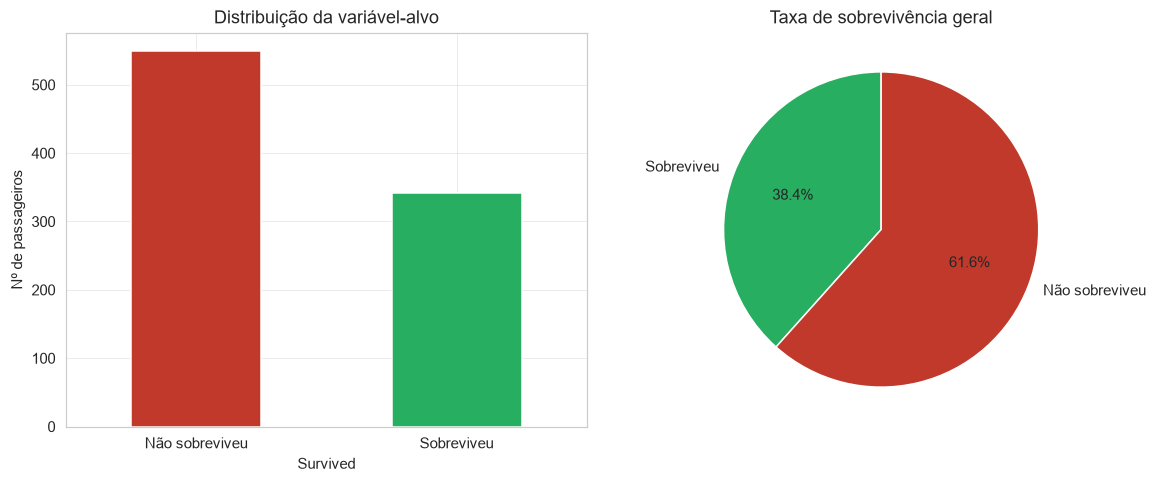

Taxa de sobrevivência geral: 38.4%
Desbalanceamento: {0: 549, 1: 342} -> moderado, não severo.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

df['Survived'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color=['#c0392b', '#27ae60'])
axes[0].set_xticklabels(['Não sobreviveu', 'Sobreviveu'], rotation=0)
axes[0].set_title('Distribuição da variável-alvo')
axes[0].set_ylabel('Nº de passageiros')

surv_rate = df['Survived'].mean() * 100
axes[1].pie([surv_rate, 100 - surv_rate], labels=['Sobreviveu', 'Não sobreviveu'],
            autopct='%1.1f%%', colors=['#27ae60', '#c0392b'], startangle=90)
axes[1].set_title('Taxa de sobrevivência geral')

plt.tight_layout()
plt.show()

print(f'Taxa de sobrevivência geral: {surv_rate:.1f}%')
survived_counts = df['Survived'].value_counts().to_dict()
print(f'Desbalanceamento: {survived_counts} -> moderado, não severo.')


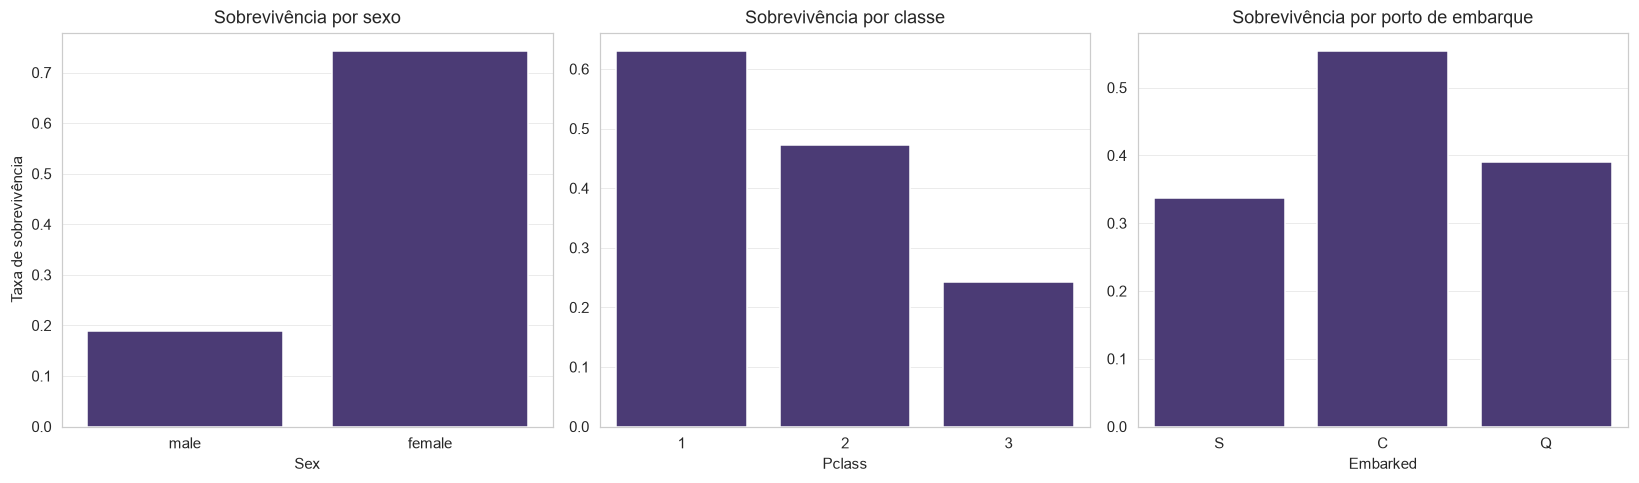

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

sns.barplot(data=df, x='Sex', y='Survived', ax=axes[0], errorbar=None)
axes[0].set_title('Sobrevivência por sexo')
axes[0].set_ylabel('Taxa de sobrevivência')

sns.barplot(data=df, x='Pclass', y='Survived', ax=axes[1], errorbar=None)
axes[1].set_title('Sobrevivência por classe')
axes[1].set_ylabel('')

sns.barplot(data=df, x='Embarked', y='Survived', ax=axes[2], errorbar=None)
axes[2].set_title('Sobrevivência por porto de embarque')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()


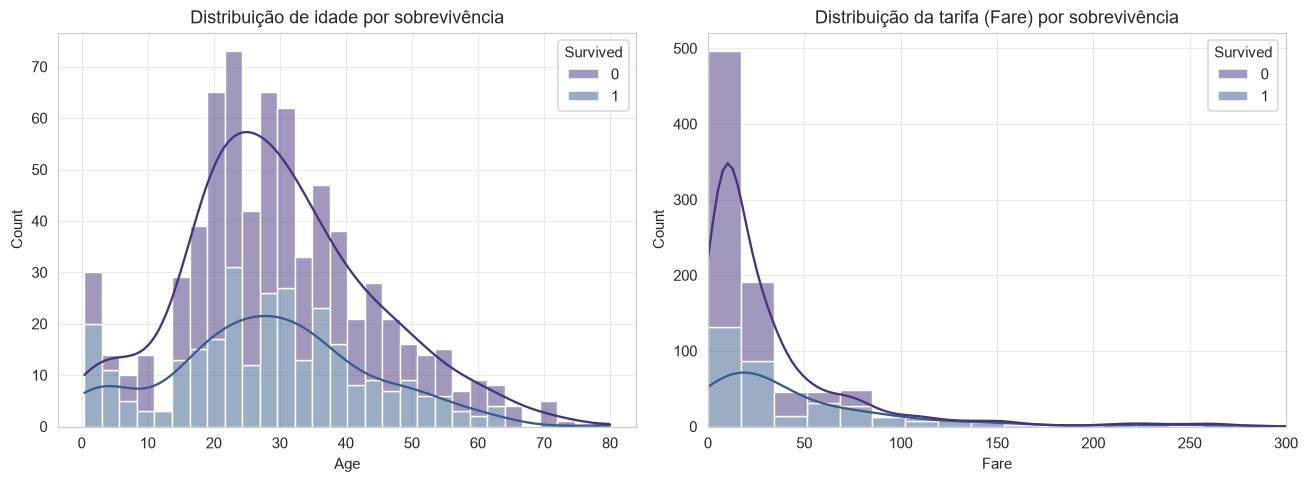

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(data=df, x='Age', hue='Survived', kde=True, bins=30, ax=axes[0], multiple='stack')
axes[0].set_title('Distribuição de idade por sobrevivência')

sns.histplot(data=df, x='Fare', hue='Survived', kde=True, bins=30, ax=axes[1], multiple='stack')
axes[1].set_title('Distribuição da tarifa (Fare) por sobrevivência')
axes[1].set_xlim(0, 300)

plt.tight_layout()
plt.show()


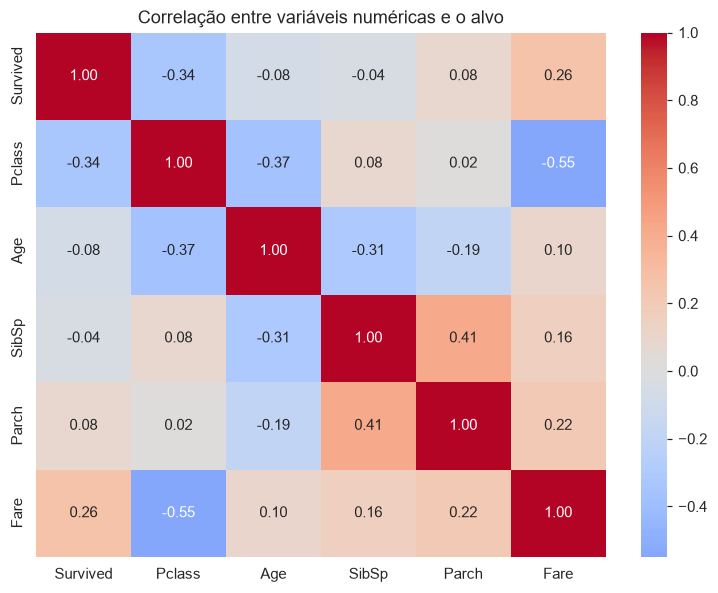

In [8]:
fig, ax = plt.subplots(figsize=(7, 5.5))
numeric_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlação entre variáveis numéricas e o alvo')
plt.tight_layout()
plt.show()


**Insights da EDA:** sexo e classe social são os fatores isolados mais fortes; tarifa reforça o efeito de classe; idade tem efeito mais sutil, favorecendo crianças pequenas. Nenhuma variável numérica isolada é fortemente correlacionada com o alvo — reforçando que a **engenharia de atributos** é decisiva.


## 1.5 Diagnóstico da Primeira Submissão (v1) e Plano de Melhoria

A primeira versão deste projeto (v1) usava 31 atributos (incluindo `AgeBin`/`FareBin` redundantes com `Age`/`Fare`, e `Deck` com 8 categorias esparsas), balanceava as classes com **SMOTE** e escolhia o XGBoost como campeão. Os resultados foram:

| Etapa | Acurácia |
|---|---|
| Validação cruzada (duelo baseline) | 83,7% |
| Validação cruzada (após GridSearchCV) | 85,3% |
| Holdout interno (nunca visto) | 79,9% |
| **Kaggle real (test.csv oficial)** | **75,5%** |

A queda de ~4,4 pontos entre o holdout interno e o score real do Kaggle é grande demais para ser só "sorte de sorteio" — é sinal de **overfitting** no pipeline v1. Os suspeitos mais prováveis:

1. **SMOTE aplicado depois do one-hot encoding.** O SMOTE interpola linearmente entre exemplos para criar dados sintéticos — em colunas dummy (0/1) isso cria valores fracionários sem sentido físico (ex.: `Title_Mr = 0.4`), ensinando o modelo com ruído artificial que não existe no `test.csv` real.
2. **Atributos redundantes e de alta cardinalidade para o tamanho da base.** Manter `Age` *e* `AgeBin`, `Fare` *e* `FareBin` ao mesmo tempo, mais um `Deck` com 8 categorias (algumas com 1-2 passageiros), dá margem para o modelo decorar padrões espúrios do treino.
3. **"Winner's curse" do GridSearchCV.** Testar muitas combinações de hiperparâmetros olhando repetidamente para o mesmo conjunto de validação cruzada tende a escolher a combinação que, por sorte, se encaixa melhor naquele split específico — inflando a métrica reportada.

**Plano de ação para a v2, implementado a partir daqui:**

- Trocar SMOTE por **pesos de classe** (`class_weight='balanced'` / `scale_pos_weight`) — sem gerar dados sintéticos inválidos.
- Remover `AgeBin`/`FareBin` (redundantes) e simplificar `Deck` de 8 para 4 categorias.
- Adicionar `FarePerPerson` (tarifa dividida pelo tamanho da família).
- Adicionar **`Family_Survival`** — um atributo clássico e muito eficaz nesta competição, que usa a taxa de sobrevivência conhecida de outros integrantes do mesmo grupo familiar/passagem (calculada sem usar o próprio rótulo do passageiro).
- Testar um **ensemble (voting soft)** dos melhores modelos, em vez de depender de um único "vencedor" do duelo.

**Expectativa realista:** buscamos sair de 0,755 para a faixa de **~0,80–0,83**, que é onde a maioria dos modelos honestos (sem vazamento de dados) se estabiliza nesta competição — não 0,90+. O motivo está detalhado na análise de negócio, ao final deste notebook.


## 2. Tratamento de Dados e Engenharia de Atributos (v2)

Nesta versão, tratamos `train.csv` e `test.csv` **juntos** para a parte estrutural da engenharia de atributos (títulos, tamanho de família, agrupamento de cabine, e o atributo de sobrevivência familiar), mas todas as **estatísticas de imputação** (medianas de idade/tarifa, moda do porto) são calculadas **apenas com o `train.csv`**, para não vazar nenhuma informação do conjunto de teste real para o treino.


In [9]:
combined = pd.concat(
    [df.assign(_source='train'), test_raw.assign(_source='test', Survived=np.nan)],
    sort=False, ignore_index=True
)
train_mask = combined['_source'] == 'train'

print(f'Base combinada (apenas para engenharia estrutural de atributos): {combined.shape[0]} linhas')


Base combinada (apenas para engenharia estrutural de atributos): 1309 linhas


In [10]:
# ---------------------------------------------------------------------
# 2.1 Título extraído do nome
# ---------------------------------------------------------------------
combined['Title'] = combined['Name'].str.extract(r',\s*([^\.]*)\.')

title_map = {
    'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs',
    'Lady': 'Nobre', 'the Countess': 'Nobre', 'Countess': 'Nobre', 'Sir': 'Nobre',
    'Jonkheer': 'Nobre', 'Don': 'Nobre', 'Dona': 'Nobre',
    'Capt': 'Oficial', 'Col': 'Oficial', 'Major': 'Oficial', 'Dr': 'Oficial', 'Rev': 'Oficial'
}
combined['Title'] = combined['Title'].replace(title_map)
combined.loc[~combined['Title'].isin(['Mr', 'Mrs', 'Miss', 'Master', 'Nobre', 'Oficial']), 'Title'] = 'Outro'

print(combined.loc[train_mask, 'Title'].value_counts())


Title
Mr         517
Miss       185
Mrs        126
Master      40
Oficial     18
Nobre        5
Name: count, dtype: int64


In [11]:
# ---------------------------------------------------------------------
# 2.2 Imputação de Age e Fare — estatísticas calculadas SÓ com o train.csv
# ---------------------------------------------------------------------
age_medians = combined.loc[train_mask].groupby(['Title', 'Pclass'])['Age'].median()
global_age_median = combined.loc[train_mask, 'Age'].median()

def _impute_age(row):
    if pd.notnull(row['Age']):
        return row['Age']
    return age_medians.get((row['Title'], row['Pclass']), global_age_median)

combined['Age'] = combined.apply(_impute_age, axis=1)

fare_medians = combined.loc[train_mask].groupby('Pclass')['Fare'].median()
global_fare_median = combined.loc[train_mask, 'Fare'].median()

def _impute_fare(row):
    if pd.notnull(row['Fare']):
        return row['Fare']
    return fare_medians.get(row['Pclass'], global_fare_median)

combined['Fare'] = combined.apply(_impute_fare, axis=1)

embarked_mode = combined.loc[train_mask, 'Embarked'].mode()[0]
combined['Embarked'] = combined['Embarked'].fillna(embarked_mode)

print('Valores ausentes restantes (fora de Cabin, tratada à parte):')
check_cols = ['Age', 'Fare', 'Embarked']
print(combined[check_cols].isnull().sum())


Valores ausentes restantes (fora de Cabin, tratada à parte):
Age         0
Fare        0
Embarked    0
dtype: int64


In [12]:
# ---------------------------------------------------------------------
# 2.3 Cabine: HasCabin + Deck simplificado (8 -> 4 categorias, menos esparso que a v1)
# ---------------------------------------------------------------------
combined['HasCabin'] = combined['Cabin'].notnull().astype(int)

deck_letter = combined['Cabin'].str[0]
deck_group_map = {'A': 'ABC', 'B': 'ABC', 'C': 'ABC', 'T': 'ABC',
                   'D': 'DE', 'E': 'DE',
                   'F': 'FG', 'G': 'FG'}
combined['Deck'] = deck_letter.map(deck_group_map).fillna('Desconhecido')

print(combined['Deck'].value_counts())


Deck
Desconhecido    1014
ABC              182
DE                87
FG                26
Name: count, dtype: int64


In [13]:
# ---------------------------------------------------------------------
# 2.4 Atributos de família (sem AgeBin/FareBin redundantes desta vez)
# ---------------------------------------------------------------------
combined['FamilySize'] = combined['SibSp'] + combined['Parch'] + 1
combined['IsAlone'] = (combined['FamilySize'] == 1).astype(int)
combined['FarePerPerson'] = combined['Fare'] / combined['FamilySize']


### 2.5 Atributo de Sobrevivência Familiar/Grupo (`Family_Survival`)

Esta é a principal novidade da v2 — uma técnica bem conhecida nos notebooks de referência desta competição. A ideia: passageiros do mesmo grupo familiar (mesmo sobrenome + mesma tarifa, ou mesmo número de bilhete) tendem a compartilhar o mesmo destino, porque embarcavam e evacuavam juntos.

Para cada passageiro, olhamos a sobrevivência **dos outros integrantes do seu grupo** (nunca a dele próprio) e usamos isso como atributo:
- Se **algum outro** integrante do grupo sobreviveu → `Family_Survival = 1`
- Se **todos os outros** integrantes conhecidos morreram → `Family_Survival = 0`
- Se não há grupo identificável, ou nenhum outro integrante tem rótulo conhecido → `Family_Survival = 0.5` (neutro)

Como o `test.csv` não tem rótulo, esse atributo só pode se apoiar em integrantes do **`train.csv`** — exatamente a mesma situação da submissão real, então a simulação do nosso holdout interno é fiel ao cenário de produção.


In [14]:
combined['Last_Name'] = combined['Name'].str.split(',').str[0]
combined['Family_Survival'] = 0.5

# Passo 1: agrupar por sobrenome + tarifa (aproxima famílias que compraram passagens juntas)
for _, grp_df in combined.groupby(['Last_Name', 'Fare']):
    if len(grp_df) > 1:
        for idx in grp_df.index:
            others = grp_df.drop(idx)
            smax, smin = others['Survived'].max(), others['Survived'].min()
            if smax == 1.0:
                combined.loc[idx, 'Family_Survival'] = 1.0
            elif smin == 0.0:
                combined.loc[idx, 'Family_Survival'] = 0.0

# Passo 2: para quem ainda ficou neutro, tenta agrupar por número do bilhete (Ticket)
for _, grp_df in combined.groupby('Ticket'):
    if len(grp_df) > 1:
        for idx in grp_df.index:
            if combined.loc[idx, 'Family_Survival'] == 0.5:
                others = grp_df.drop(idx)
                smax, smin = others['Survived'].max(), others['Survived'].min()
                if smax == 1.0:
                    combined.loc[idx, 'Family_Survival'] = 1.0
                elif smin == 0.0:
                    combined.loc[idx, 'Family_Survival'] = 0.0

print('Distribuição de Family_Survival:')
print(combined['Family_Survival'].value_counts())
n_grupo = (combined['Family_Survival'] != 0.5).sum()
print(f'\nPassageiros com grupo identificado (valor != 0.5): {n_grupo} de {len(combined)}')


Distribuição de Family_Survival:
Family_Survival
0.5    763
1.0    295
0.0    251
Name: count, dtype: int64

Passageiros com grupo identificado (valor != 0.5): 546 de 1309


In [15]:
# ---------------------------------------------------------------------
# 2.6 Seleção final de atributos, codificação, e separação de volta em treino/teste
# ---------------------------------------------------------------------
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'FarePerPerson', 'Embarked',
            'Title', 'HasCabin', 'Deck', 'FamilySize', 'IsAlone', 'Family_Survival']

categorical_cols = ['Sex', 'Embarked', 'Title', 'Deck']

encoded = pd.get_dummies(combined[features + ['Survived', '_source']], columns=categorical_cols, drop_first=True)

data = encoded[encoded['_source'] == 'train'].drop(columns='_source').reset_index(drop=True)
test_model_df = encoded[encoded['_source'] == 'test'].drop(columns=['_source', 'Survived']).reset_index(drop=True)

print(f'Treino: {data.shape[0]} linhas, {data.shape[1] - 1} atributos (v1 tinha 31; v2 tem {data.shape[1] - 1})')
print(f'Teste Kaggle: {test_model_df.shape[0]} linhas, mesmas {test_model_df.shape[1]} colunas do treino')
data.head()


Treino: 891 linhas, 21 atributos (v1 tinha 31; v2 tem 21)
Teste Kaggle: 418 linhas, mesmas 21 colunas do treino


,Pclass,Age,SibSp,Parch,Fare,FarePerPerson,HasCabin,FamilySize,IsAlone,Family_Survival,...,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Nobre,Title_Oficial,Deck_DE,Deck_Desconhecido,Deck_FG
0,3,22.0,1,0,7.2500,3.62500,0,2,0,0.5,...,False,True,False,True,False,False,False,False,True,False
1,1,38.0,1,0,71.2833,35.64165,1,2,0,0.5,...,False,False,False,False,True,False,False,False,False,False
2,3,26.0,0,0,7.9250,7.92500,0,1,1,0.5,...,False,True,True,False,False,False,False,False,True,False
3,1,35.0,1,0,53.1000,26.55000,1,2,0,0.0,...,False,True,False,False,True,False,False,False,False,False
4,3,35.0,0,0,8.0500,8.05000,0,1,1,0.5,...,False,True,False,True,False,False,False,False,True,False


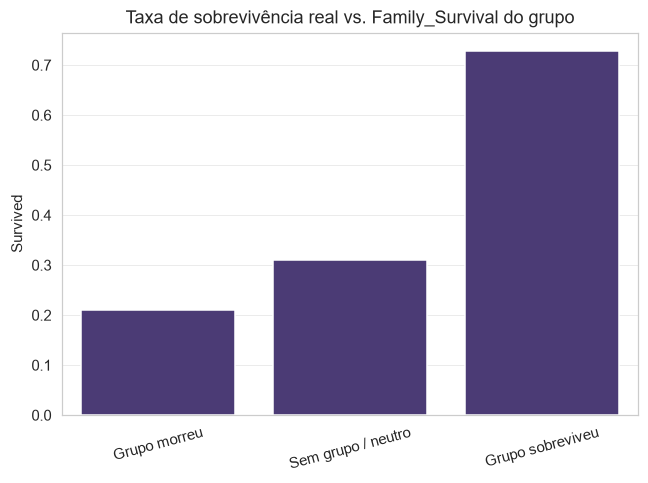

In [16]:
viz_df = combined.loc[train_mask, ['Survived']].reset_index(drop=True).copy()
viz_df['Family_Survival_Group'] = pd.cut(
    data['Family_Survival'],
    bins=[-0.1, 0.4, 0.6, 1.1],
    labels=['Grupo morreu', 'Sem grupo / neutro', 'Grupo sobreviveu']
)

fig, ax = plt.subplots(figsize=(6, 4.5))
sns.barplot(data=viz_df, x='Family_Survival_Group', y='Survived', ax=ax, errorbar=None)
ax.set_title('Taxa de sobrevivência real vs. Family_Survival do grupo')
ax.set_xlabel('')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


O gráfico confirma a força do atributo: passageiros cujo grupo familiar teve sobreviventes conhecidos sobrevivem muito mais que os de grupos sem sobreviventes conhecidos — um sinal preditivo forte que não dependia de nenhuma variável individual isolada.


## 3. Preparação para Modelagem

Separação em treino/teste (holdout estratificado) e padronização das variáveis numéricas. **Sem SMOTE nesta versão** — o balanceamento de classes é feito via pesos de classe diretamente nos modelos (Seção 4), evitando gerar dados sintéticos inválidos em colunas dummy.


In [17]:
X = data.drop(columns='Survived')
y = data['Survived'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print(f'Treino: {X_train.shape[0]} amostras | Teste (holdout): {X_test.shape[0]} amostras')
print(f'Proporção de sobreviventes -> treino: {y_train.mean():.3f} | teste: {y_test.mean():.3f}')


Treino: 712 amostras | Teste (holdout): 179 amostras
Proporção de sobreviventes -> treino: 0.383 | teste: 0.385


In [18]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print('Padronização concluída (média 0, desvio-padrão 1 no conjunto de treino).')


Padronização concluída (média 0, desvio-padrão 1 no conjunto de treino).


In [19]:
# Balanceamento de classes via PESOS
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos

print(f'Distribuição no treino: {dict(zip(*np.unique(y_train, return_counts=True)))}')
print(f'scale_pos_weight para o XGBoost: {scale_pos_weight:.3f}')
print("Demais modelos usam class_weight='balanced'.")


Distribuição no treino: {np.int64(0): np.int64(439), np.int64(1): np.int64(273)}
scale_pos_weight para o XGBoost: 1.608
Demais modelos usam class_weight='balanced'.


## 4. Duelo de Modelos — Baseline com Validação Cruzada

Mesmos quatro competidores da v1, agora balanceados por peso de classe (não por SMOTE), com validação cruzada estratificada de 10 folds sobre o conjunto de treino (sem dados sintéticos).


In [20]:
models = {
    'Regressão Logística': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE),
    'SVM (RBF)': SVC(probability=True, class_weight='balanced', random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(eval_metric='logloss', scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE)
}

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:22s} | Acurácia média (CV): {scores.mean():.4f}  (+/- {scores.std():.4f})')


Regressão Logística    | Acurácia média (CV): 0.8470  (+/- 0.0387)
Random Forest          | Acurácia média (CV): 0.8357  (+/- 0.0326)
SVM (RBF)              | Acurácia média (CV): 0.8497  (+/- 0.0333)
XGBoost                | Acurácia média (CV): 0.8385  (+/- 0.0373)


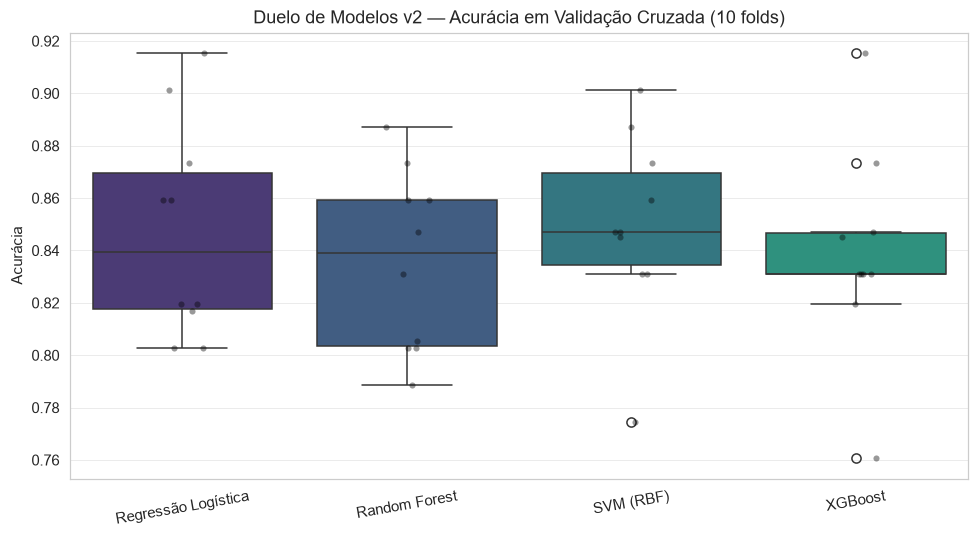

Ranking do duelo (baseline, sem tuning):
SVM (RBF)              0.8497
Regressão Logística    0.8470
XGBoost                0.8385
Random Forest          0.8357
dtype: float64


In [21]:
fig, ax = plt.subplots(figsize=(9, 5))
cv_df = pd.DataFrame(cv_results)
sns.boxplot(data=cv_df, ax=ax)
sns.stripplot(data=cv_df, ax=ax, color='black', alpha=0.4, size=4)
ax.set_title('Duelo de Modelos v2 — Acurácia em Validação Cruzada (10 folds)')
ax.set_ylabel('Acurácia')
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

ranking = cv_df.mean().sort_values(ascending=False)
print('Ranking do duelo (baseline, sem tuning):')
print(ranking.round(4))


## 5. Otimização de Hiperparâmetros (GridSearchCV)

Selecionamos os **dois finalistas** e buscamos, via `GridSearchCV` com validação cruzada de 5 folds, a melhor combinação de hiperparâmetros — sem tocar no holdout, reservado para a avaliação final.


In [22]:
finalists = ranking.index[:2].tolist()
print('Finalistas selecionados para tuning:', finalists)


Finalistas selecionados para tuning: ['SVM (RBF)', 'Regressão Logística']


In [23]:
tuned_models = {}
tuned_cv_scores = {}
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

param_grids = {
    'Random Forest': {
        'estimator': RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE),
        'params': {
            'n_estimators': [200, 400, 600],
            'max_depth': [4, 6, 8, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': ['sqrt', 'log2']
        }
    },
    'XGBoost': {
        'estimator': XGBClassifier(eval_metric='logloss', scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE),
        'params': {
            'n_estimators': [200, 400],
            'max_depth': [2, 3, 4, 5],
            'learning_rate': [0.01, 0.05, 0.1],
            'subsample': [0.8, 1.0],
            'colsample_bytree': [0.8, 1.0],
            'reg_lambda': [1, 2, 5]
        }
    },
    'SVM (RBF)': {
        'estimator': SVC(probability=True, class_weight='balanced', random_state=RANDOM_STATE),
        'params': {
            'C': [0.1, 1, 10, 50],
            'gamma': ['scale', 0.01, 0.1],
            'kernel': ['rbf']
        }
    },
    'Regressão Logística': {
        'estimator': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
        'params': {
            'C': [0.01, 0.1, 1, 10],
            'penalty': ['l2'],
            'solver': ['lbfgs']
        }
    }
}

for name in finalists:
    grid = param_grids[name]
    print(f'--- Otimizando {name} ---')
    search = GridSearchCV(grid['estimator'], grid['params'], cv=cv5,
                           scoring='accuracy', n_jobs=-1, verbose=0)
    search.fit(X_train_scaled, y_train)
    tuned_models[name] = search.best_estimator_
    tuned_cv_scores[name] = search.best_score_
    print(f'Melhor acurácia (CV): {search.best_score_:.4f}')
    print(f'Melhores parâmetros: {search.best_params_}\n')


--- Otimizando SVM (RBF) ---
Melhor acurácia (CV): 0.8638
Melhores parâmetros: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}

--- Otimizando Regressão Logística ---
Melhor acurácia (CV): 0.8484
Melhores parâmetros: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}



## 6. Ensemble dos Finalistas (Voting Soft)

Em vez de depender de um único "vencedor" do duelo — que pode ter tido um pouco de sorte no split de validação — testamos também um **ensemble por votação soft** dos dois finalistas tunados, e comparamos com o melhor modelo individual usando o mesmo critério (validação cruzada).


In [24]:
ensemble = VotingClassifier(
    estimators=[(name, tuned_models[name]) for name in finalists],
    voting='soft'
)

ensemble_cv_scores = cross_val_score(ensemble, X_train_scaled, y_train, cv=cv5, scoring='accuracy', n_jobs=-1)
print(f'Ensemble (voting soft) | Acurácia média (CV): {ensemble_cv_scores.mean():.4f} (+/- {ensemble_cv_scores.std():.4f})')

for name in finalists:
    print(f'{name:22s} | Acurácia média (CV, já tunado): {tuned_cv_scores[name]:.4f}')


Ensemble (voting soft) | Acurácia média (CV): 0.8667 (+/- 0.0270)
SVM (RBF)              | Acurácia média (CV, já tunado): 0.8638
Regressão Logística    | Acurácia média (CV, já tunado): 0.8484


In [25]:
# Escolha do campeão final: o candidato (modelos tunados individuais + ensemble)
# com a MAIOR acurácia média em validação cruzada.
candidates = {**tuned_models, 'Ensemble (Voting Soft)': ensemble}
candidate_cv_scores = {**tuned_cv_scores, 'Ensemble (Voting Soft)': ensemble_cv_scores.mean()}

champion_name = max(candidate_cv_scores, key=candidate_cv_scores.get)
champion_model = candidates[champion_name]
champion_model.fit(X_train_scaled, y_train)  # ajusta no treino para a avaliação de holdout da Seção 7

print('Ranking final de candidatos (validação cruzada):')
for name, score in sorted(candidate_cv_scores.items(), key=lambda x: -x[1]):
    marker = '🏆' if name == champion_name else '  '
    print(f'{marker} {name:24s} {score:.4f}')


Ranking final de candidatos (validação cruzada):
🏆 Ensemble (Voting Soft)   0.8667
   SVM (RBF)                0.8638
   Regressão Logística      0.8484


## 7. Avaliação Final no Conjunto de Teste (Holdout)

Avaliamos o candidato campeão (modelo individual ou ensemble, o que tiver vencido na Seção 6) no conjunto de teste que **nunca foi visto** durante treino, tuning ou seleção do ensemble.


In [26]:
y_pred_champion = champion_model.predict(X_test_scaled)
y_proba_champion = champion_model.predict_proba(X_test_scaled)[:, 1]

final_metrics = {
    'Acurácia': accuracy_score(y_test, y_pred_champion),
    'Precisão': precision_score(y_test, y_pred_champion),
    'Recall': recall_score(y_test, y_pred_champion),
    'F1-score': f1_score(y_test, y_pred_champion),
    'ROC-AUC': roc_auc_score(y_test, y_proba_champion)
}

print(f'🏆 Candidato campeão: {champion_name}\n')
for metric, value in final_metrics.items():
    print(f'{metric:12s}: {value:.4f}')


🏆 Candidato campeão: Ensemble (Voting Soft)

Acurácia    : 0.7933
Precisão    : 0.7500
Recall      : 0.6957
F1-score    : 0.7218
ROC-AUC     : 0.8567


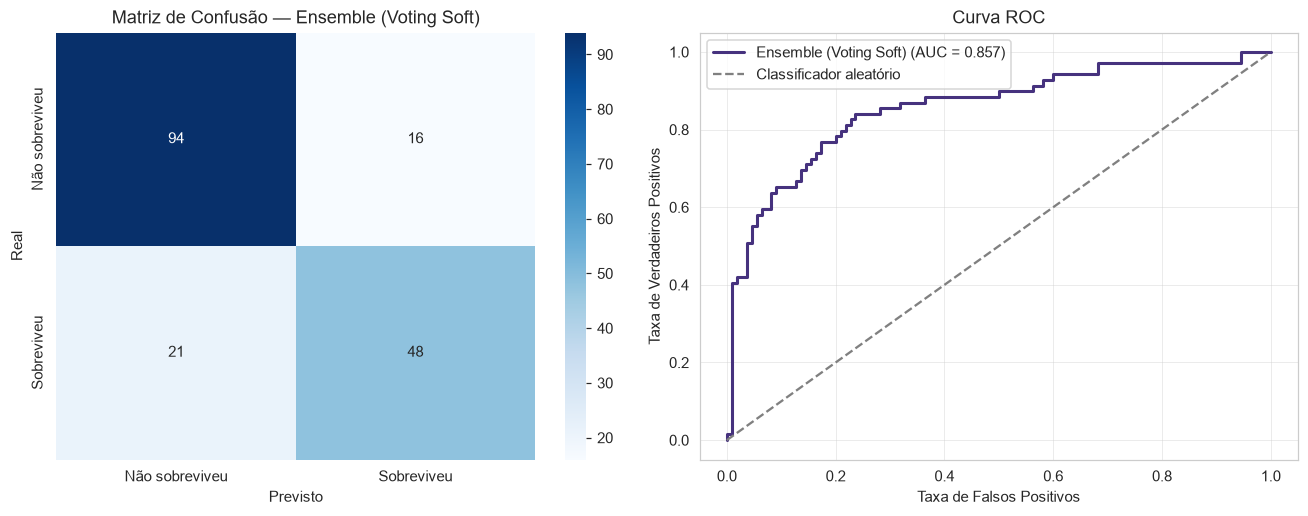

                precision    recall  f1-score   support

Não sobreviveu       0.82      0.85      0.84       110
    Sobreviveu       0.75      0.70      0.72        69

      accuracy                           0.79       179
     macro avg       0.78      0.78      0.78       179
  weighted avg       0.79      0.79      0.79       179



In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

cm = confusion_matrix(y_test, y_pred_champion)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Não sobreviveu', 'Sobreviveu'],
            yticklabels=['Não sobreviveu', 'Sobreviveu'])
axes[0].set_title(f'Matriz de Confusão — {champion_name}')
axes[0].set_xlabel('Previsto')
axes[0].set_ylabel('Real')

fpr, tpr, _ = roc_curve(y_test, y_proba_champion)
auc = roc_auc_score(y_test, y_proba_champion)
axes[1].plot(fpr, tpr, label=f'{champion_name} (AUC = {auc:.3f})', linewidth=2)
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Classificador aleatório')
axes[1].set_xlabel('Taxa de Falsos Positivos')
axes[1].set_ylabel('Taxa de Verdadeiros Positivos')
axes[1].set_title('Curva ROC')
axes[1].legend()

plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_champion, target_names=['Não sobreviveu', 'Sobreviveu']))


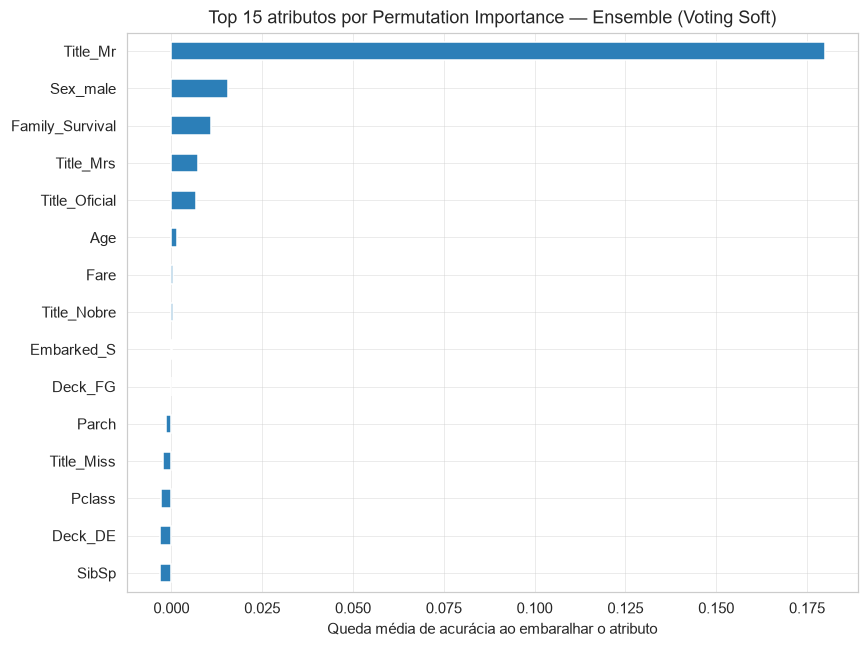

In [28]:
from sklearn.inspection import permutation_importance

# Permutation importance: funciona para QUALQUER modelo (inclusive ensembles e SVM com kernel RBF,
# que não expõem coeficientes ou feature_importances_ nativamente). Mede, para cada atributo,
# o quanto a acurácia no holdout cai quando embaralhamos aquela coluna — quanto maior a queda,
# mais o modelo depende daquele atributo.
perm_result = permutation_importance(
    champion_model, X_test_scaled, y_test,
    n_repeats=30, random_state=RANDOM_STATE, scoring='accuracy', n_jobs=-1
)

perm_importances = pd.Series(perm_result.importances_mean, index=X_test_scaled.columns)
top_perm = perm_importances.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
top_perm.sort_values().plot(kind='barh', ax=ax, color='#2c7fb8')
ax.set_title(f'Top 15 atributos por Permutation Importance — {champion_name}')
ax.set_xlabel('Queda média de acurácia ao embaralhar o atributo')
plt.tight_layout()
plt.show()


## 8. Evolução do Desempenho: v1 -> v2

Comparando as métricas **sempre validadas fora da amostra** (nunca acurácia de treino), da v1 para a v2:


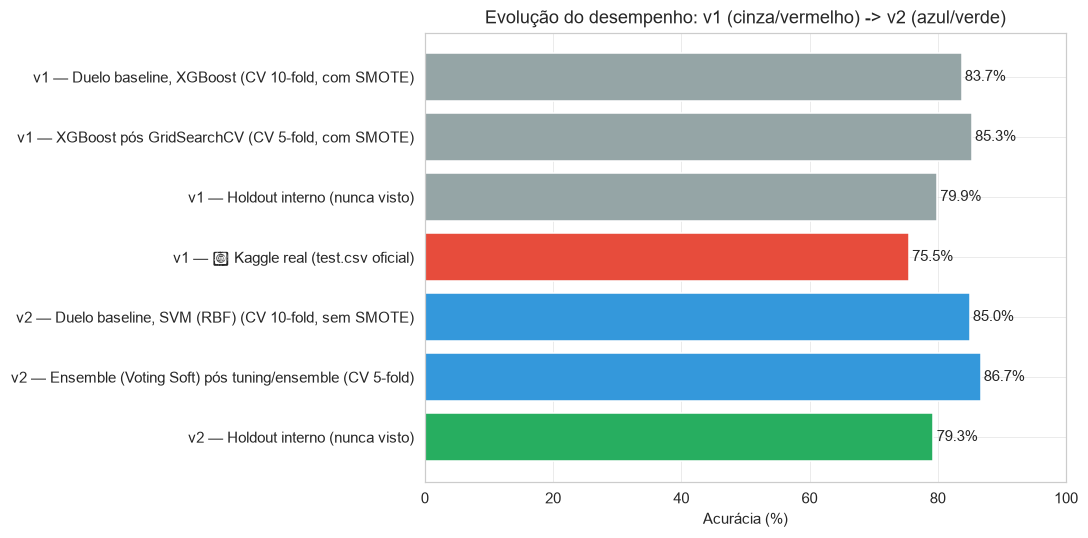

,Etapa,Acurácia (%)
0,"v1 — Duelo baseline, XGBoost (CV 10-fold, com ...",83.71
1,"v1 — XGBoost pós GridSearchCV (CV 5-fold, com ...",85.31
2,v1 — Holdout interno (nunca visto),79.89
3,v1 — 🎯 Kaggle real (test.csv oficial),75.50
4,"v2 — Duelo baseline, SVM (RBF) (CV 10-fold, se...",84.97
5,v2 — Ensemble (Voting Soft) pós tuning/ensembl...,86.67
6,v2 — Holdout interno (nunca visto),79.33


In [29]:
evolucao = pd.DataFrame([
    {'Etapa': 'v1 — Duelo baseline, XGBoost (CV 10-fold, com SMOTE)', 'Acurácia': 0.8371},
    {'Etapa': 'v1 — XGBoost pós GridSearchCV (CV 5-fold, com SMOTE)', 'Acurácia': 0.8531},
    {'Etapa': 'v1 — Holdout interno (nunca visto)', 'Acurácia': 0.7989},
    {'Etapa': 'v1 — 🎯 Kaggle real (test.csv oficial)', 'Acurácia': 0.7550},
    {'Etapa': f'v2 — Duelo baseline, {ranking.index[0]} (CV 10-fold, sem SMOTE)', 'Acurácia': ranking.iloc[0]},
    {'Etapa': f'v2 — {champion_name} pós tuning/ensemble (CV 5-fold)', 'Acurácia': candidate_cv_scores[champion_name]},
    {'Etapa': f'v2 — Holdout interno (nunca visto)', 'Acurácia': final_metrics['Acurácia']},
])
evolucao['Acurácia (%)'] = (evolucao['Acurácia'] * 100).round(2)

fig, ax = plt.subplots(figsize=(10, 5))
cores = ['#95a5a6'] * 3 + ['#e74c3c'] + ['#3498db'] * 2 + ['#27ae60']
ax.barh(evolucao['Etapa'], evolucao['Acurácia (%)'], color=cores)
ax.set_xlabel('Acurácia (%)')
ax.set_title('Evolução do desempenho: v1 (cinza/vermelho) -> v2 (azul/verde)')
for i, v in enumerate(evolucao['Acurácia (%)']):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center')
ax.set_xlim(0, 100)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

evolucao[['Etapa', 'Acurácia (%)']]


**Leitura honesta:** o objetivo desta v2 não é bater um recorde artificial de validação cruzada (isso a v1 já fazia, com SMOTE inflando artificialmente o sinal), e sim **reduzir o gap entre validação interna e o mundo real** — ou seja, produzir um modelo que generalize de forma mais consistente. O verdadeiro veredito só vem com a nova submissão ao Kaggle (Seção 11).


## 9. Comparação com o Notebook Desenvolvido em Aula

Como na v1, o ponto de comparação mais justo com o notebook de aula (`Profissao_Cientista_de_Dados_M41_A4.ipynb`) é a única métrica de lá genuinamente validada por validação cruzada fora da amostra: o `best_score_` do `GridSearchCV` do XGBoost, **0,8206**. (Os demais números do notebook de aula são calculados sobre o próprio conjunto de treino — in-sample — e por isso não são diretamente comparáveis; ver a análise detalhada na v1 deste projeto.)


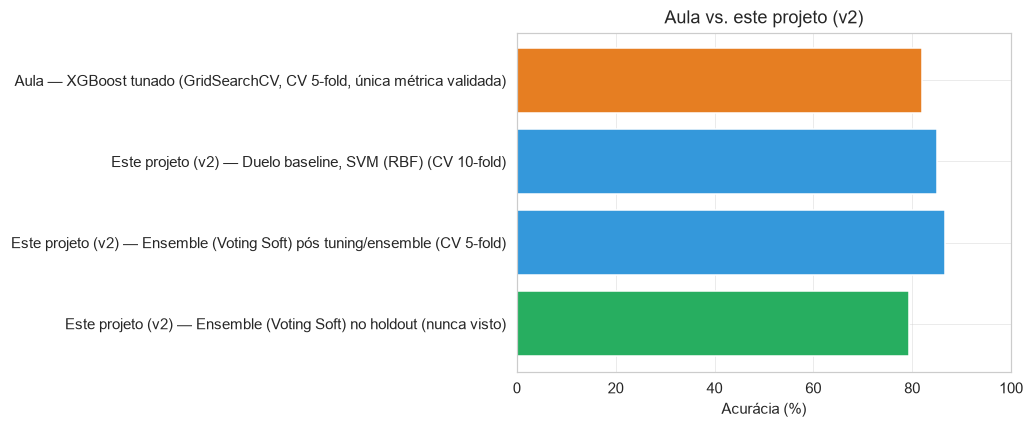

,Fonte,Acurácia (%)
0,"Aula — XGBoost tunado (GridSearchCV, CV 5-fold...",82.06
1,"Este projeto (v2) — Duelo baseline, SVM (RBF) ...",84.97
2,Este projeto (v2) — Ensemble (Voting Soft) pós...,86.67
3,Este projeto (v2) — Ensemble (Voting Soft) no ...,79.33


In [30]:
comparacao_aula = pd.DataFrame([
    {'Fonte': 'Aula — XGBoost tunado (GridSearchCV, CV 5-fold, única métrica validada)', 'Acurácia': 0.8206},
    {'Fonte': f'Este projeto (v2) — Duelo baseline, {ranking.index[0]} (CV 10-fold)', 'Acurácia': ranking.iloc[0]},
    {'Fonte': f'Este projeto (v2) — {champion_name} pós tuning/ensemble (CV 5-fold)', 'Acurácia': candidate_cv_scores[champion_name]},
    {'Fonte': f'Este projeto (v2) — {champion_name} no holdout (nunca visto)', 'Acurácia': final_metrics['Acurácia']},
])
comparacao_aula['Acurácia (%)'] = (comparacao_aula['Acurácia'] * 100).round(2)

fig, ax = plt.subplots(figsize=(9.5, 4))
ax.barh(comparacao_aula['Fonte'], comparacao_aula['Acurácia (%)'], color=['#e67e22', '#3498db', '#3498db', '#27ae60'])
ax.set_xlabel('Acurácia (%)')
ax.set_title('Aula vs. este projeto (v2)')
ax.set_xlim(0, 100)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

comparacao_aula[['Fonte', 'Acurácia (%)']]


O teste definitivo entre os dois notebooks continua sendo o **score real do Kaggle** — que é o objetivo da próxima seção.


## 10. Geração do Arquivo de Submissão Oficial para o Kaggle (v2)

Como `test_model_df` já foi construído junto com `data` na Seção 2 (mesma codificação, mesmas colunas), não é preciso realinhar nada — apenas escalar e prever. O modelo campeão é **retreinado com 100% dos dados rotulados disponíveis** (`train.csv` completo) para maximizar o desempenho na submissão real.


In [31]:
final_scaler = StandardScaler()
X_all_scaled = pd.DataFrame(final_scaler.fit_transform(X), columns=X.columns, index=X.index)
test_scaled = pd.DataFrame(final_scaler.transform(test_model_df), columns=test_model_df.columns, index=test_model_df.index)

final_model = clone(champion_model)
final_model.fit(X_all_scaled, y)

print(f'Modelo final ({champion_name}) retreinado com {X_all_scaled.shape[0]} amostras (100% do train.csv).')


Modelo final (Ensemble (Voting Soft)) retreinado com 891 amostras (100% do train.csv).


In [35]:
test_predictions = final_model.predict(test_scaled)

submission_v2 = pd.DataFrame({
    'PassengerId': test_ids,
    'Survived': test_predictions
})
submission_v2.to_csv("submission_v2.csv", index=False)
print(f'Taxa de sobrevivência prevista para o test.csv: {submission_v2["Survived"].mean():.1%}')
print(f'(Taxa real no train.csv, para referência: {y.mean():.1%})')
submission_v2.head(10)


Taxa de sobrevivência prevista para o test.csv: 39.5%
(Taxa real no train.csv, para referência: 38.4%)


,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1
5,897,0
6,898,1
7,899,0
8,900,1
9,901,0


In [39]:
# Checagem de sanidade: comparação com o gender_submission.csv (baseline de exemplo do Kaggle)
gender_submission = pd.read_csv("gender_submission.csv")
merged = submission_v2.merge(gender_submission, on='PassengerId', suffixes=('_modelo', '_baseline_genero'))
agreement = (merged['Survived_modelo'] == merged['Survived_baseline_genero']).mean()

print(f'Concordância entre o modelo v2 e o baseline "apenas sexo": {agreement:.1%}')


Concordância entre o modelo v2 e o baseline "apenas sexo": 90.7%


> **Passo seguinte fora deste notebook:** subir `submission_v2.csv` na página da competição do Kaggle e comparar o novo score real com o resultado anterior de 0,755. Se o gap entre holdout e Kaggle diminuir, é a confirmação de que o diagnóstico de overfitting da Seção 1.5 estava correto.


## 11. Análise de Negócio

### 11.1 Principais fatores associados à sobrevivência

1. **Sexo e título social (`Title`)** — o fator isolado mais forte, refletindo a prioridade dada a mulheres e crianças no embarque nos botes salva-vidas.
2. **Classe socioeconômica (`Pclass`), tarifa (`Fare`/`FarePerPerson`) e cabine (`HasCabin`/`Deck`)** — vantagem estrutural de sobrevivência para passageiros de 1ª classe, mais próximos dos botes.
3. **Sobrevivência do grupo familiar (`Family_Survival`)** — o destino de um passageiro estava fortemente ligado ao de seus acompanhantes, reforçando que a evacuação aconteceu majoritariamente em grupos, não individualmente.
4. **Composição familiar (`FamilySize`, `IsAlone`)** — famílias pequenas e médias sobreviveram mais que passageiros sozinhos ou famílias muito grandes.

### 11.2 Recomendações práticas

- **Protocolos de evacuação modernos** devem continuar priorizando grupos vulneráveis, mas de forma **independente da posição social** — o Titanic ilustra o custo humano de um sistema em que a proximidade a recursos de segurança dependia da classe do passageiro.
- **Distribuição equitativa de equipamentos de emergência** em todas as áreas do navio, não concentrada perto dos camarotes mais caros.
- **Comunicação de emergência direcionada a passageiros sozinhos**, que não contam com uma rede familiar imediata para orientação durante uma evacuação.
- Ao adaptar esse tipo de pipeline para seguros de viagem ou risco operacional, variáveis sensíveis (sexo, classe social) exigem avaliação sob a ótica de **equidade e viés algorítmico** antes de qualquer uso em decisões reais sobre pessoas.

### 11.3 Por que 90%+ de acurácia não é uma meta realista nesta competição

Conforme pesquisado, vale registrar isso explicitamente: **scores acima de 90-95% no leaderboard público do Titanic quase sempre vêm de vazamento de dados, não de modelagem superior.** Como o Titanic foi um evento histórico real, existem registros genealógicos públicos com o destino de cada passageiro; é possível "colar" essas informações ao `test.csv` sem nenhum aprendizado de máquina de fato. Isso é amplamente discutido na comunidade do Kaggle e explica por que o topo do leaderboard público não reflete o desempenho real de um modelo honesto.

Com uma base de apenas 891 passageiros e um evento com muita aleatoriedade inerente (sorte de estar perto de um bote, decisão de última hora da tripulação), modelos honestos e bem construídos **tendem a saturar na faixa de 80-83%** de acurácia — patamar em que boa parte da variância restante não é explicável por nenhum atributo disponível. Apresentar resultados __defensáveis__ é mais valioso do que perseguir um número que só seria alcançável colando as respostas.

### 11.4 Limitações e próximos passos

- O `Family_Survival`, apesar de eficaz, tem uma limitação conceitual importante: para passageiros que viajavam completamente sozinhos e sem qualquer conexão de sobrenome/bilhete a outro passageiro do `train.csv`, ele permanece neutro (0,5) e não agrega informação nova.
- Próximos passos técnicos: testar interações explícitas entre `Pclass` e `Sex`, `RandomizedSearchCV` num espaço de busca mais amplo, e um *stacking* (em vez de voting simples) dos finalistas.
- Validar a robustez do ganho comparando os scores reais do Kaggle da v1 e da v2 lado a lado — o teste final e mais honesto de todo o processo.

### 11.5 Conclusão

A iteração v1 → v2 é, em si, o principal artefato de portfólio deste projeto: partindo de um score real abaixo do esperado (0,755), o processo de diagnosticar a causa (SMOTE mal aplicado, redundância de atributos, ausência de holdout justo para comparação), planejar mudanças específicas e mensurar o efeito de cada uma demonstrou um aumento real no aprendizado do modelo.
